In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

db = sqlite3.connect("C:\\Users\\Lenovo\\Desktop\\Studia\\WSzI\\deep-learning-project\\data\\chembl_36\\chembl_36_sqlite\\chembl_36.db")

def query(sql: str):
    return pd.read_sql(sql, db)

# Cel

Stworzenie modelu regresji aktywności biologicznej molekuły czyli przewidujemy liczbę/funkcję liczbową aktywności na określony target biologiczny na podstawie jej cech chemicznych.

## Molecules
Neutralne elektrycznie grupy dwóch lub więcej atomów, które sąpołączone wiązaniami chemicznymi, tworząc najmniejszą stabilną cząstke substancji zachowującą jej właściwości chemiczne

## Activities
Są to wyniki eksperymentów biologicznych, zawiera konkretne wyniki bioaktywności

## Assays
To eksperyment lub test biologiczy

## Targets
To cele biologiczne, tu są wszystkie białka, komórki, organizmy, na które działają molekuły


In [3]:
print("Molecules:", query("SELECT COUNT(*) AS n FROM molecule_dictionary")["n"][0])
print("Activities:", query("SELECT COUNT(*) AS n FROM activities")["n"][0])
print("Assays:", query("SELECT COUNT(*) AS n FROM assays")["n"][0])
print("Targets:", query("SELECT COUNT(*) AS n FROM target_dictionary")["n"][0])

Molecules: 2878135
Activities: 24267312
Assays: 1890749
Targets: 17803


## Faza kliniczna
Etap badań leku na ludziach, na jakim poziomie rozwoju znajduje się dany kandydat na lek

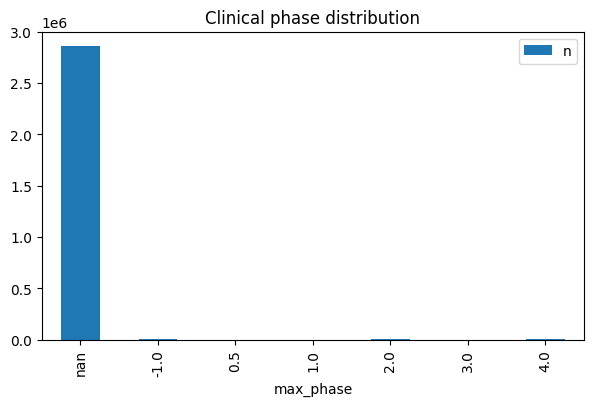

,max_phase,n
0,NaN,2858825
1,-1.0,2530
2,0.5,26
3,1.0,1616
4,2.0,9150
5,3.0,1983
6,4.0,4005


In [4]:
df = query("""
            SELECT max_phase, COUNT(*) as n
           from molecule_dictionary
           group by max_phase
           order by max_phase          
           """)

df.plot.bar(x = 'max_phase', y='n', title="Clinical phase distribution", figsize=(7,4))
plt.show()
df

## Masa molowa
To masa jednego mola danej substancji chemicznej, wyrażana zazwyczja w gramach na mol (g/mol). Jest to wielkość fizyczna, która liczbowo jest równa masie cząsteczkowej (dla cząsteczek) lub masie atomowej (dla atomów)

Powiązanie z molekułą po `molregno`

           full_mwt
count  2.858458e+06
mean   4.430681e+02
std    2.597625e+02
min    4.000000e+00
25%    3.331700e+02
50%    4.044400e+02
75%    4.874700e+02
max    1.254632e+04


<Axes: title={'center': 'Molecular Weight Distribution'}, ylabel='Frequency'>

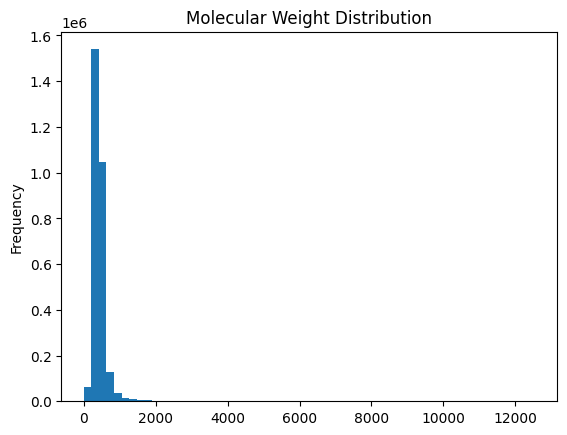

In [5]:
df_mwt = query("SELECT full_mwt from compound_properties WHERE full_mwt is not null")

print(df_mwt.describe())

df_mwt["full_mwt"].plot.hist(bins=60, title="Molecular Weight Distribution")

## logP
Logarytm dziesiętny wspólczynnika podziału między oktanol a wodę

- logP > 0 - cząsteczka hydrofobowa, lubi tłuszcze, słabo rozpuszcza się w wodzie
- logP < 0 - cząsteczka hydrofilowa, dobrze rozpuszcza się w wodzie
- logP ~~ 2-3 - często optymalne dla leków doustnych (wg Lipińskiego)

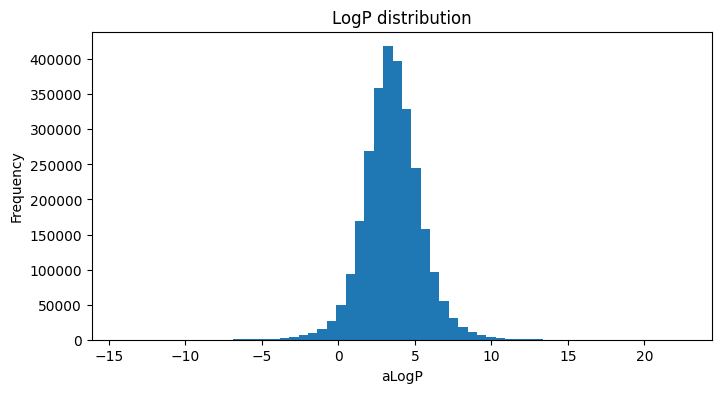

,alogp
count,2.784347e+06
mean,3.524149e+00
std,1.868393e+00
min,-1.426000e+01
25%,2.400000e+00
50%,3.490000e+00
75%,4.630000e+00
max,2.257000e+01


In [6]:
df_logp = query ("SELECT alogp from compound_properties where alogp is not null;")

df_logp['alogp'].plot.hist(bins=60, figsize=(8,4), title="LogP distribution")
plt.xlabel("aLogP")
plt.show()
df_logp.describe()

## Targety

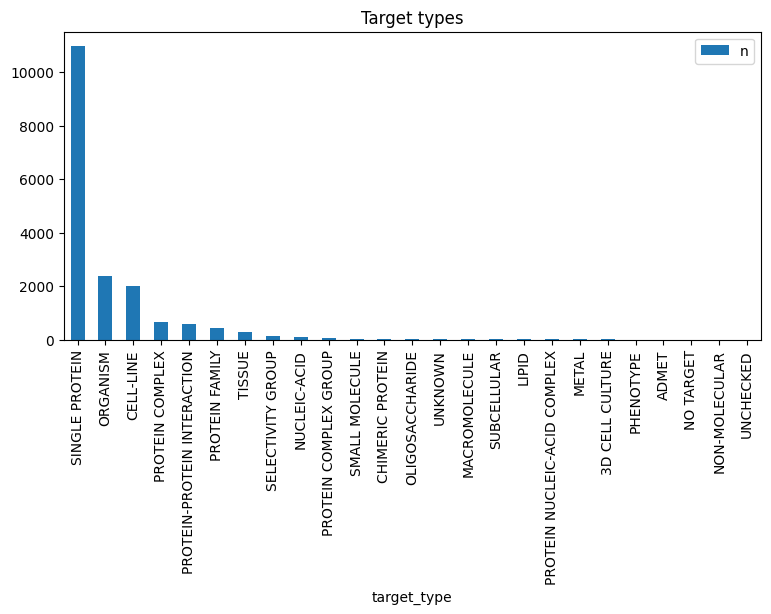

,target_type,n
0,SINGLE PROTEIN,10962
1,ORGANISM,2383
2,CELL-LINE,1997
3,PROTEIN COMPLEX,645
4,PROTEIN-PROTEIN INTERACTION,596
5,PROTEIN FAMILY,428
6,TISSUE,294
7,SELECTIVITY GROUP,123
8,NUCLEIC-ACID,112
9,PROTEIN COMPLEX GROUP,66


In [7]:
df_ttypes = query("select target_type, count(*) as n from target_dictionary group by target_type order by n desc;")
df_ttypes.plot.bar(x="target_type", y="n", figsize=(9,4), title="Target types")
plt.show()
df_ttypes

## Organizmy
docelowe

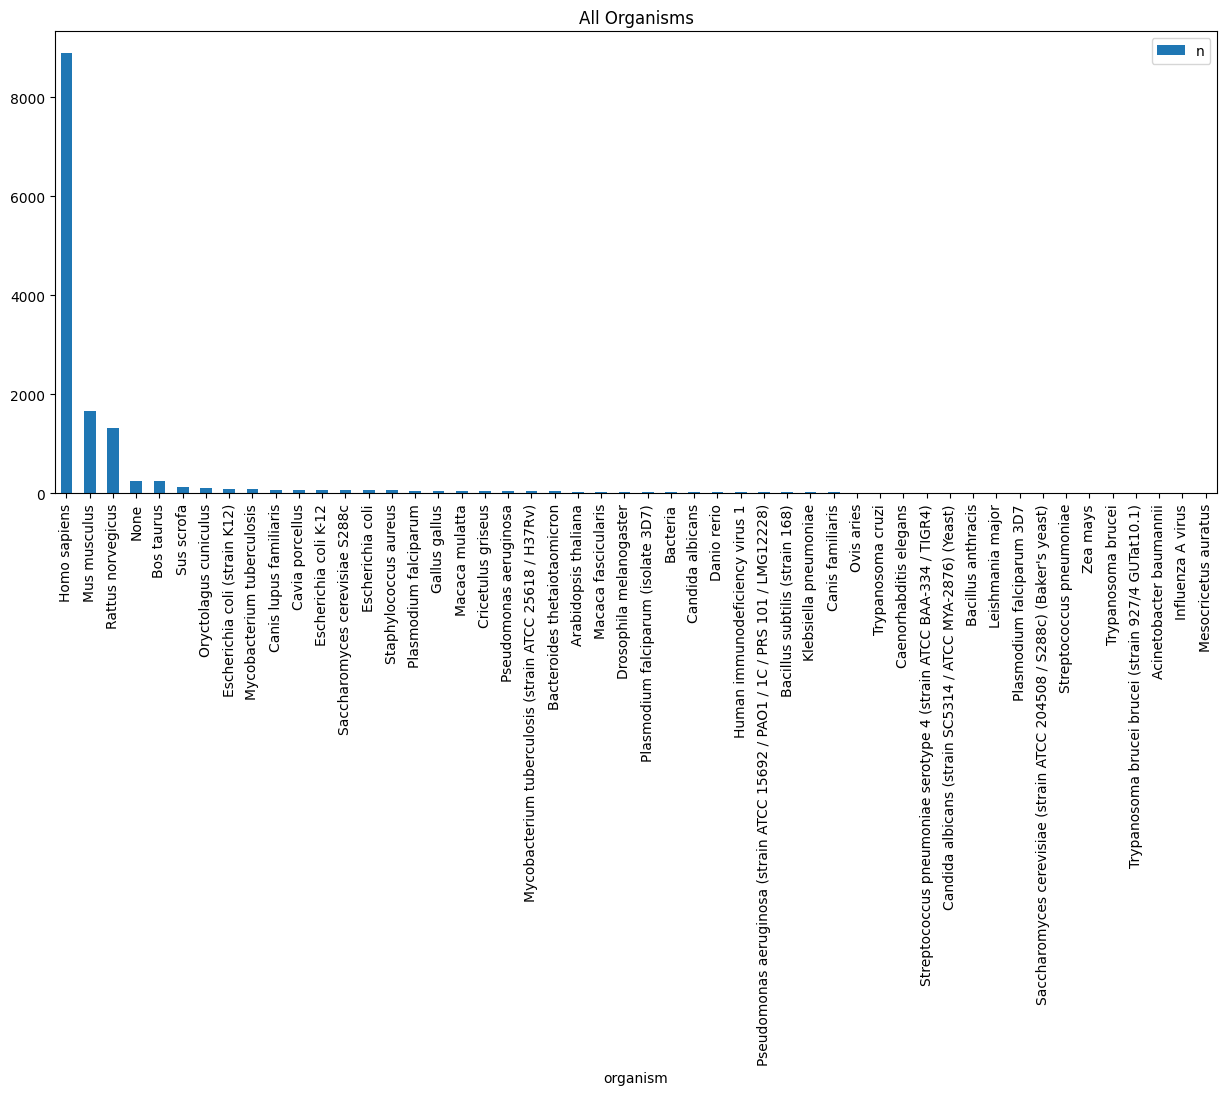

,organism,n
0,Homo sapiens,8886
1,Mus musculus,1670
2,Rattus norvegicus,1331
3,None,247
4,Bos taurus,247
5,Sus scrofa,134
6,Oryctolagus cuniculus,109
7,Escherichia coli (strain K12),93
8,Mycobacterium tuberculosis,89
9,Canis lupus familiaris,79


In [8]:
df_org = query("select organism, count(*) as n from target_dictionary group by organism order by n desc limit 50;")
df_org.plot.bar(x="organism", y="n", figsize=(15,6), title="All Organisms")
plt.show()
df_org

# Aktywności

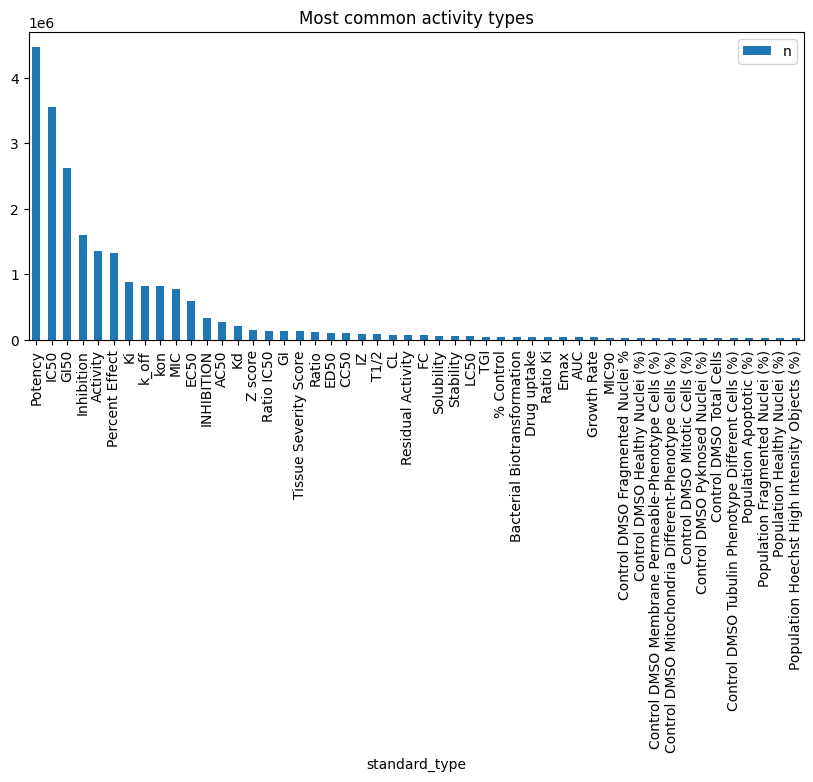

,standard_type,n
0,Potency,4473542
1,IC50,3552865
2,GI50,2629061
3,Inhibition,1593108
4,Activity,1357448
5,Percent Effect,1328366
6,Ki,880730
7,k_off,826806
8,kon,826637
9,MIC,780708


In [9]:
df_atypes = query("""
select standard_type, count(*) as n
from activities
where standard_type is not null
group by standard_type
order by n desc
limit 50;
""")

df_atypes.plot.bar(x="standard_type", y="n", figsize=(10,4), title="Most common activity types")
plt.show()
df_atypes

## Rozkład IC50 - log10

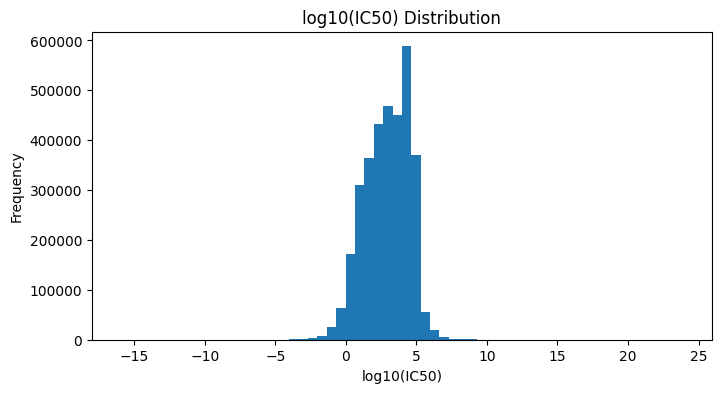

,standard_value,log10_ic50
count,3.343409e+06,3.343409e+06
mean,1.385132e+18,2.910176e+00
std,8.163491e+20,1.563441e+00
min,1.000000e-16,-1.600000e+01
25%,5.710000e+01,1.756636e+00
50%,1.000000e+03,3.000000e+00
75%,1.240000e+04,4.093422e+00
max,8.912509e+23,2.395000e+01


In [10]:
df_ic50 = query("""
    SELECT standard_value
    FROM activities
    WHERE standard_type = 'IC50'
      AND standard_value > 0;
""")

import numpy as np
df_ic50["log10_ic50"] = np.log10(df_ic50["standard_value"])

df_ic50["log10_ic50"].plot.hist(bins=60, figsize=(8,4), title="log10(IC50) Distribution")
plt.xlabel("log10(IC50)")
plt.show()
df_ic50.describe()

## Najpopularniejsze targety

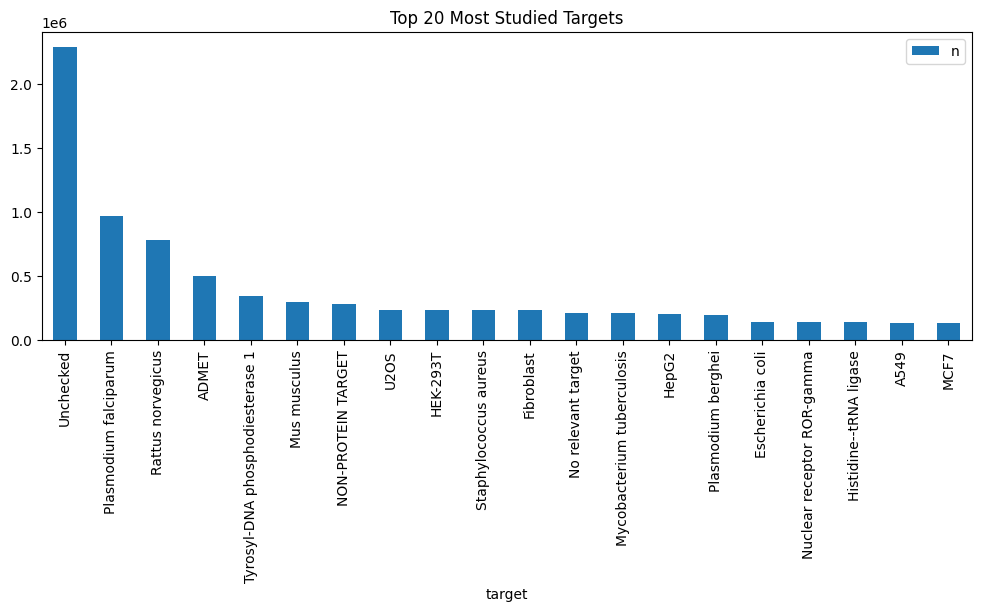

,target,n
0,Unchecked,2291439
1,Plasmodium falciparum,971671
2,Rattus norvegicus,778099
3,ADMET,496635
4,Tyrosyl-DNA phosphodiesterase 1,345574
5,Mus musculus,293389
6,NON-PROTEIN TARGET,283329
7,U2OS,234502
8,HEK-293T,234165
9,Staphylococcus aureus,232257


In [11]:
df_pop_targets = query("""
    SELECT t.pref_name AS target, COUNT(*) AS n
    FROM activities a
    JOIN assays s ON a.assay_id = s.assay_id
    JOIN target_dictionary t ON s.tid = t.tid
    GROUP BY t.pref_name
    ORDER BY n DESC
    LIMIT 20;
""")

df_pop_targets.plot.bar(x="target", y="n", figsize=(12,4), title="Top 20 Most Studied Targets")
plt.show()
df_pop_targets

## Jakie jednostki występują w bazie

In [12]:
df_units = query("""
    SELECT standard_units, COUNT(*) AS n
    FROM activities
    WHERE standard_units IS NOT NULL
    GROUP BY standard_units
    ORDER BY n DESC
""")
df_units

,standard_units,n
0,nM,12587576
1,%,5200597
2,ug.mL-1,952582
3,s-1,828026
4,uM,257898
...,...,...
2694,ug/hr.ml,1
2695,ug/m2/day,1
2696,um3.um2/day,1
2697,umol/min/nmol,1


## Najczęściej występująca jednostka dla `standard_type`
Czy każdy `standard_type` przekonwertować do najpopularniejszej jednostki, jeśli występuje ich więcej w bazie?

In [13]:
df_units = query("""
    SELECT standard_type, standard_units, COUNT(*) AS n
    FROM activities
    WHERE standard_type IS NOT NULL
    GROUP BY standard_type, standard_units
""")

df_top_units = df_units.loc[df_units.groupby("standard_type")["n"].idxmax()]
df_top_units

,standard_type,standard_units,n
0,%,None,32
2,% Activity remaining,%,280
3,% Cell Death,None,2400
4,% Control,%,50544
5,% Ctrl,%,2885
...,...,...,...
14588,tRNA peak exclusion,%,8
14589,tox/total,None,26
14590,tz,hr,9
14591,washout,%,1
